## Titanic Survival Prediction
Professional ML pipeline.

In [12]:
# =========================================
# 1. Import Libraries
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

## Load Dataset

In [13]:
# =========================================
# 2. Load Dataset
# =========================================

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

## Data Preprocessing & Feature Engineering

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

df = train_df.copy()

# =========================
# 1. BASIC CLEANING
# =========================

df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# =========================
# 2. BETTER AGE IMPUTATION
# =========================

age_features = ["Pclass", "Sex", "SibSp", "Parch", "Fare"]

temp = df.copy()
temp["Sex"] = temp["Sex"].map({"male": 0, "female": 1})

known_age = temp[temp["Age"].notna()]
unknown_age = temp[temp["Age"].isna()]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    known_age[age_features],
    known_age["Age"]
)

df.loc[df["Age"].isna(), "Age"] = rf.predict(
    unknown_age[age_features]
)

# =========================
# 3. FEATURE ENGINEERING
# =========================

# Encode Sex

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# -------------------------
# Title
# -------------------------

df["Title"] = df["Name"].str.extract(
    " ([A-Za-z]+)\.",
    expand=False
)

df["Title"] = df["Title"].replace(
    ["Mlle", "Ms"],
    "Miss"
)

df["Title"] = df["Title"].replace(
    ["Mme"],
    "Mrs"
)

df["Title"] = df["Title"].replace(
    [
        "Lady","Countess","Capt","Col",
        "Don","Dr","Major","Rev",
        "Sir","Jonkheer","Dona"
    ],
    "Rare"
)

# -------------------------
# Child Feature
# -------------------------

df["Child"] = (df["Age"] < 16).astype(int)

# -------------------------
# Mother Feature
# -------------------------

df["Mother"] = (
    (df["Sex"] == 1) &
    (df["Parch"] > 0) &
    (df["Age"] >= 18) &
    (df["Title"] == "Mrs")
).astype(int)

# -------------------------
# Ticket Prefix
# -------------------------

df["TicketPrefix"] = (
    df["Ticket"]
    .str.replace(r"[./]", "", regex=True)
    .str.extract(r"([A-Za-z]+)", expand=False)
    .fillna("NONE")
)

# -------------------------
# Ticket Group Size
# -------------------------

ticket_counts = df["Ticket"].value_counts()
df["TicketGroupSize"] = df["Ticket"].map(ticket_counts)

# -------------------------
# Deck Feature
# -------------------------

df["Deck"] = (
    df["Cabin"]
    .str[0]
    .fillna("U")
)

# -------------------------
# Family Features
# -------------------------

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (
    df["FamilySize"] == 1
).astype(int)

df["SmallFamily"] = (
    df["FamilySize"].between(2,4)
).astype(int)

df["LargeFamily"] = (
    df["FamilySize"] >= 5
).astype(int)

# -------------------------
# Family Category
# -------------------------

df["FamilyCategory"] = pd.cut(
    df["FamilySize"],
    bins=[0,1,4,20],
    labels=[
        "Alone",
        "Small",
        "Large"
    ]
)

# -------------------------
# Fare Features
# -------------------------

df["Fare_log"] = np.log1p(df["Fare"])

df["Fare_per_person"] = (
    df["Fare"] / df["FamilySize"]
)

# -------------------------
# Fare Binning
# -------------------------

df["FareBin"] = pd.qcut(
    df["Fare"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "VeryHigh"
    ]
)

# -------------------------
# Age Binning
# -------------------------

df["AgeBin"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=[
        "Child",
        "Teen",
        "YoungAdult",
        "Adult",
        "Senior"
    ]
)

# -------------------------
# Interaction Features
# -------------------------

df["Sex*Pclass"] = (
    df["Sex"] * df["Pclass"]
)

df["Age*Pclass"] = (
    df["Age"] * df["Pclass"]
)

df["Pclass*Fare"] = (
    df["Pclass"] * df["Fare_log"]
)

df["SexTitle"] = (
    df["Sex"].astype(str)
    + "_"
    + df["Title"].astype(str)
)

# =========================
# 4. ENCODING
# =========================

df = pd.get_dummies(
    df,
    columns=[
        "Embarked",
        "Title",
        "AgeBin",
        "FareBin",
        "TicketPrefix",
        "Deck",
        "FamilyCategory",
        "SexTitle"
    ],
    drop_first=True
)

# =========================
# 5. DROP UNUSED COLUMNS
# =========================

df.drop(
    columns=[
        "Name",
        "Ticket",
        "Cabin",
        "PassengerId"
    ],
    inplace=True
)

# =========================
# 6. FINAL CLEANING
# =========================

df["Fare_per_person"] = (
    df["Fare_per_person"]
    .replace([np.inf, -np.inf], np.nan)
)

df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

# =========================
# 7. TRAIN / TEST SPLIT
# =========================

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# 8. FINAL CHECK
# =========================

print("NaNs total:", X_train.isnull().sum().sum())
print("Object columns:", X_train.select_dtypes(include="object").columns)
print("Training shape:", X_train.shape)

<>:54: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:54: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\VICTUS 16\AppData\Local\Temp\ipykernel_9888\436959749.py:54: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  " ([A-Za-z]+)\.",


NaNs total: 0
Object columns: Index([], dtype='str')
Training shape: (712, 74)


## Logistic Regression Baseline

In [15]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



c:\Users\VICTUS 16\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Random Forest Model

In [16]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



## XGBoost Model

In [17]:
#XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8491620111731844
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       105
           1       0.83      0.80      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



## Feature Importance

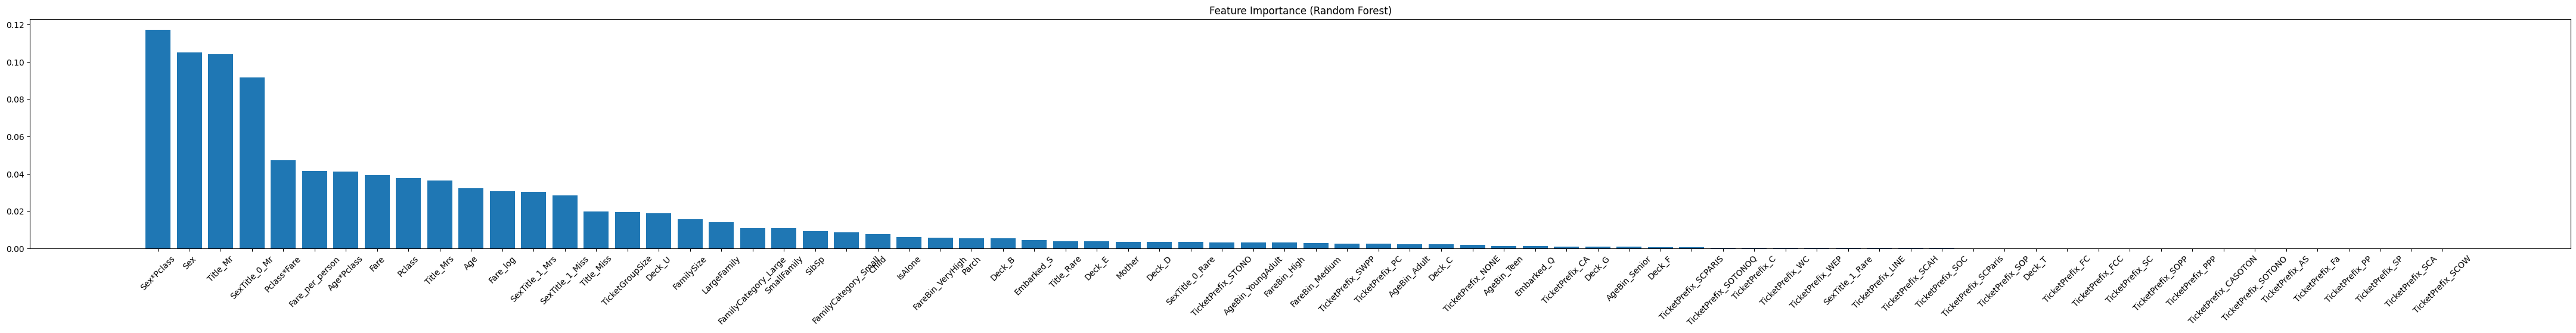

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(55, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance (Random Forest)")
plt.show()

## Model Comparison

In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, model.predict(X_test)),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.821229
1,Random Forest,0.815642
2,XGBoost,0.849162


## XGBoost Cross Validation

In [20]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

CV Scores: [0.86592179 0.84269663 0.83146067 0.8258427  0.85393258]
Mean Accuracy: 0.8439708743958321
Std: 0.014613951545323854


## Voting Ensemble

In [21]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# =========================
# 1. MODELS
# =========================

log_clf = LogisticRegression(max_iter=1000)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)

# =========================
# 2. ENSEMBLE MODEL
# =========================

ensemble = VotingClassifier(
    estimators=[
        ("lr", log_clf),
        ("rf", rf_clf),
        ("xgb", xgb_clf)
    ],
    voting="soft"
)

# =========================
# 3. CROSS VALIDATION
# =========================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    ensemble,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

# =========================
# 4. RESULTS
# =========================

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

c:\Users\VICTUS 16\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\VICTUS 16\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    h

CV Scores: [0.8547486  0.84269663 0.81460674 0.84831461 0.85393258]
Mean Accuracy: 0.8428598330299417
Std: 0.014778139587847707
